In [1]:
import pandas as pd
pd.set_option ('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/datos_unidos.csv")

In [3]:
df["estado_marital"].unique()

array([66,  6,  4,  5,  1,  2, 77, 88, 99,  3])

In [5]:
df["estado_marital"] = df["estado_marital"].replace([66, 77, 88, 99], np.nan)

In [7]:
marital_dic = {
    1: "casado legalmente",
    2: "union legal",
    3: "separado legalmente",
    4: "divorciado legalmente",
    5: "viudo",
    6: "soltero"
}


In [8]:
df["estado_marital"] = df["estado_marital"].replace(marital_dic)

In [14]:
df["estado_marital"].unique()

array([nan, 'soltero', 'divorciado legalmente', 'viudo',
       'casado legalmente', 'union legal', 'separado legalmente'],
      dtype=object)

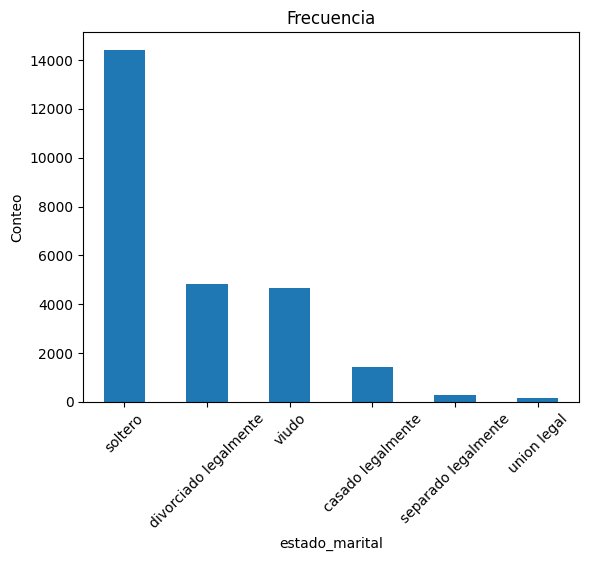

In [16]:
plt.figure()
df["estado_marital"].value_counts().plot(kind="bar")
plt.title(f"Frecuencia")
plt.xlabel("estado_marital")
plt.ylabel("Conteo")
plt.xticks(rotation=45)
plt.show()

In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,50116.0,78150.556589,38146.018647,50002.0,60020.0,69947.5,80048.0,273842.0
edad,49723.0,51.593749,18.661027,15.0,37.0,52.0,67.0,90.0
año_nacimiento,49723.0,1971.789655,18.676766,1933.0,1957.0,1971.0,1987.0,2009.0
años_educacion,49213.0,13.244732,4.002987,0.0,11.0,13.0,16.0,50.0
decil_ingresos,39688.0,5.404026,2.752342,1.0,3.0,5.0,8.0,10.0
satisfaccion_vida,49752.0,6.995679,2.152700,0.0,6.0,7.0,8.0,10.0
felicidad,49897.0,7.314548,1.912394,0.0,6.0,8.0,9.0,10.0
reuniones_sociales,49981.0,4.763170,1.600793,1.0,4.0,5.0,6.0,7.0
deporte,49333.0,3.225306,2.624059,0.0,1.0,3.0,6.0,7.0
horas_trabajo,42220.0,38.802179,13.971707,0.0,37.0,40.0,45.0,132.0


In [18]:
df["edad"] = df["edad"].replace([666, 777, 888, 999], np.nan)


In [23]:
df["año_nacimiento"] = df["año_nacimiento"].replace([6666,7777,8888,9999], np.nan)

In [32]:
df["años_educacion"] = df["años_educacion"].replace([67, 69, 77,88, 99], np.nan)

In [77]:
df["horas_trabajo"] = df["horas_trabajo"].replace([140, 144, 145, 150, 151, 155,156,158,160, 162, 164, 165, 167, 168, 666, 777, 888,999], np.nan)

In [69]:
df["problemas_sueño"] = df["problemas_sueño"].replace([6, 7, 8, 9], np.nan)

In [71]:
df["interes_politica"] = df["interes_politica"].replace([6, 7, 8, 9], np.nan)

In [73]:
df["importancia_tradiciones"] = df["importancia_tradiciones"].replace([66], np.nan)

In [75]:
df["uso_internet"] = df["uso_internet"].replace([7,8,9], np.nan)

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50116 entries, 0 to 50115
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       50116 non-null  int64  
 1   pais                     50116 non-null  str    
 2   edad                     49723 non-null  float64
 3   año_nacimiento           49723 non-null  float64
 4   sexo                     50116 non-null  str    
 5   años_educacion           49213 non-null  float64
 6   estado_marital           25806 non-null  object 
 7   decil_ingresos           39688 non-null  float64
 8   satisfaccion_vida        49752 non-null  float64
 9   felicidad                49897 non-null  float64
 10  reuniones_sociales       49981 non-null  float64
 11  deporte                  49333 non-null  float64
 12  horas_trabajo            42220 non-null  float64
 13  problemas_sueño          49915 non-null  float64
 14  interes_politica         50021 no

Vamos a crear una nueva columna que dice a qué generacion pertenece la persona.

In [84]:
def generacion(year):
    if pd.isna(year):
        return np.nan
    elif 1946 <= year <= 1964:
        return "Baby Boomers"
    elif 1965 <= year <= 1980:
        return "Gen X"
    elif 1981 <= year <= 1996:
        return "Millennials"
    elif 1997 <= year <= 2012:
        return "Gen Z"
    else:
        return "Other"

df["generacion"] = df["año_nacimiento"].apply(generacion)

In [85]:
df["generacion"].value_counts()

generacion
Baby Boomers    15283
Gen X           13566
Millennials     11047
Gen Z            5978
Other            3849
Name: count, dtype: int64

In [86]:
df["generacion"].value_counts(normalize=True) * 100

generacion
Baby Boomers    30.736279
Gen X           27.283149
Millennials     22.217083
Gen Z           12.022605
Other            7.740885
Name: proportion, dtype: float64

Hay dos variables (interés política y importancia de la tradiciones), donde voy a cambiar la escala, porque está al revés (o sea, 1 significa mucho interés y 4 poco). Creo que se entenderá mejor si 4 es mayor interés que 1. 

In [89]:
df["interes_politica"] = df["interes_politica"].replace({
    1: 4,
    2: 3,
    3: 2,
    4: 1
})

In [90]:
df["importancia_tradiciones"] = df["importancia_tradiciones"].replace({
    1: 6,
    2: 5,
    3: 4,
    4: 3,
    5: 2,
    6: 1
})

In [91]:
numeric_cols = df.select_dtypes(include="number").columns

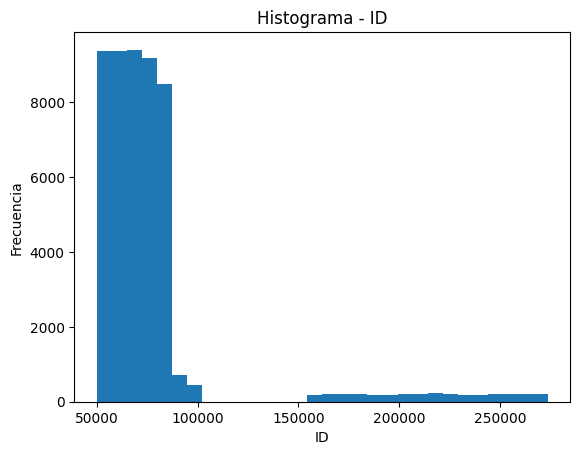

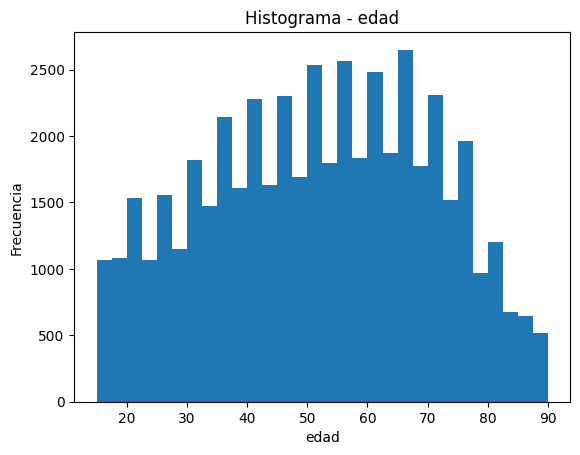

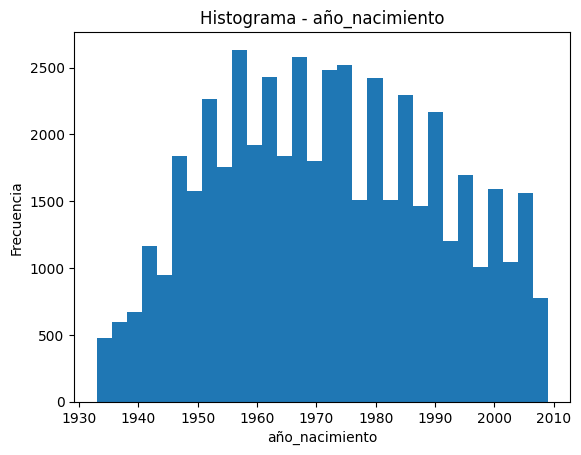

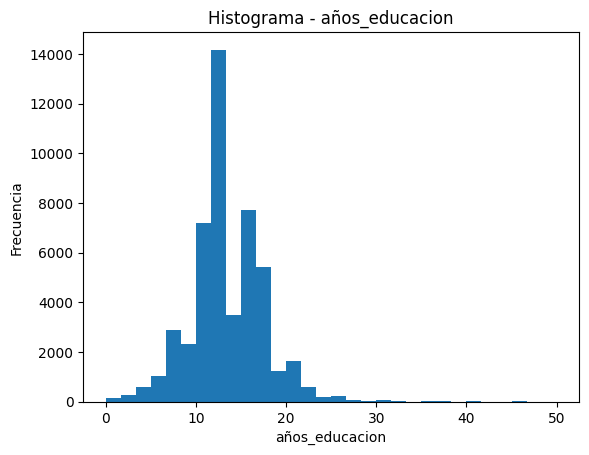

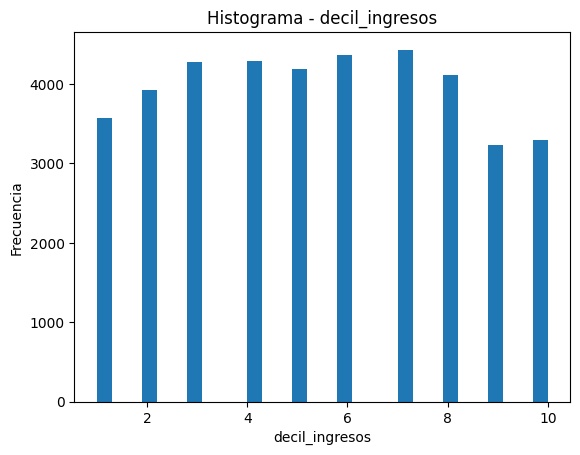

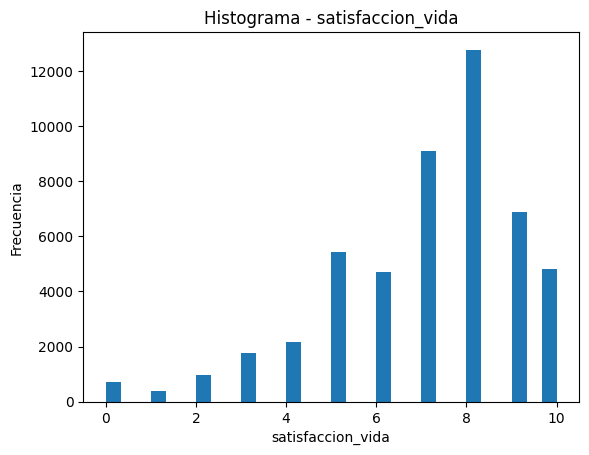

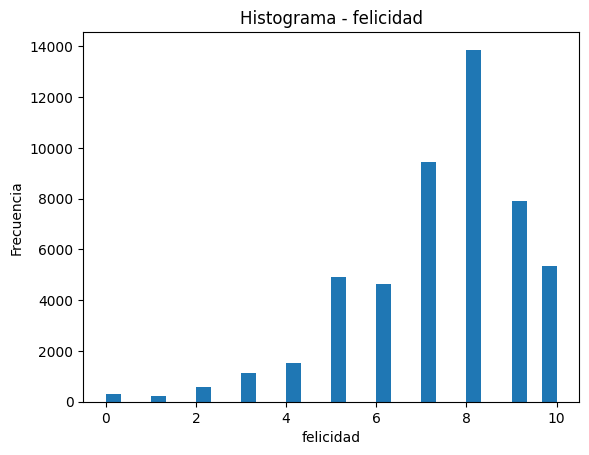

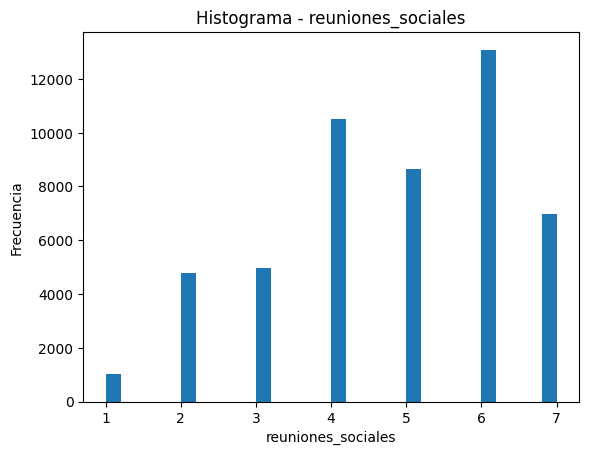

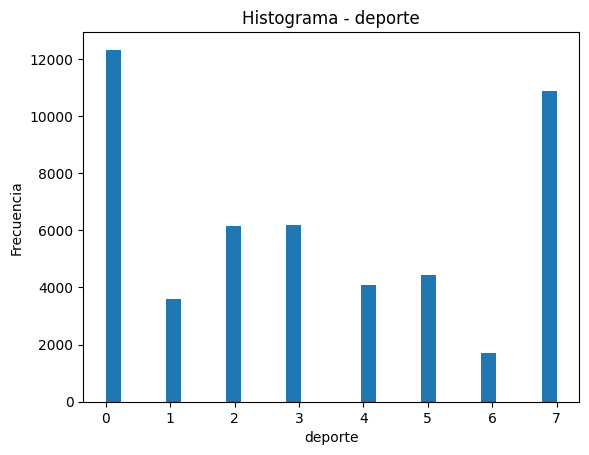

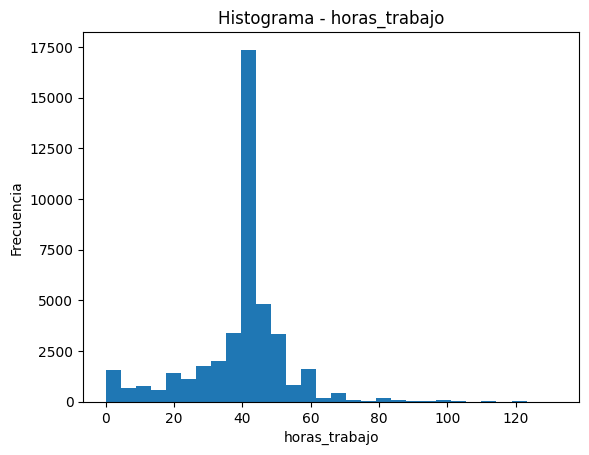

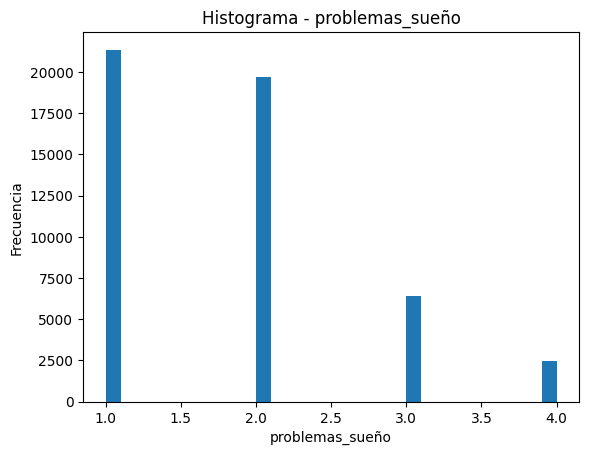

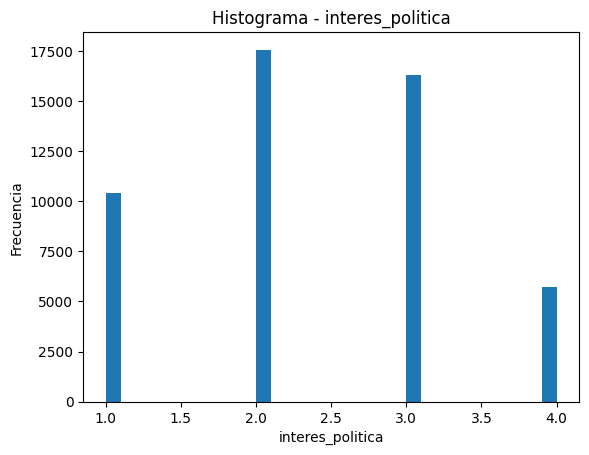

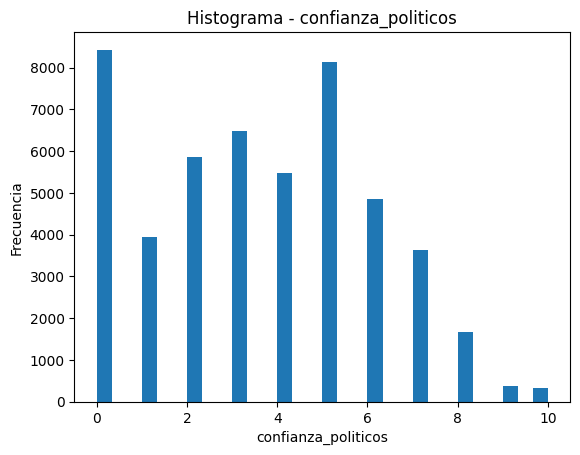

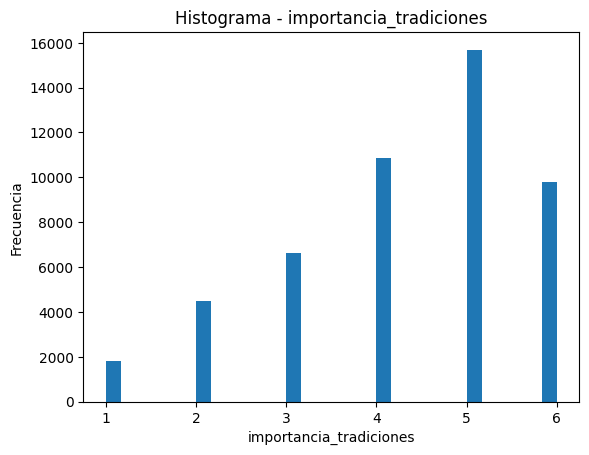

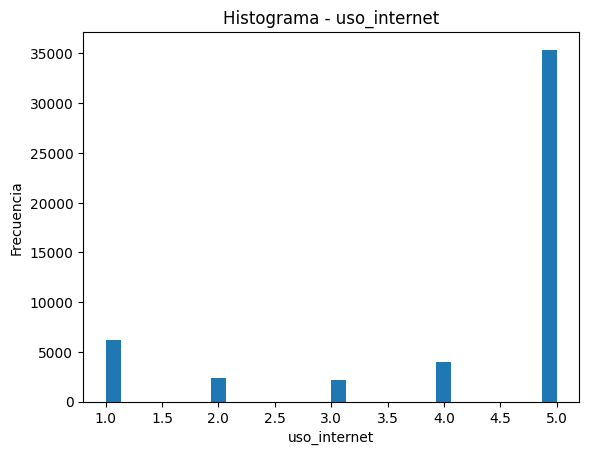

In [92]:
for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histograma - {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

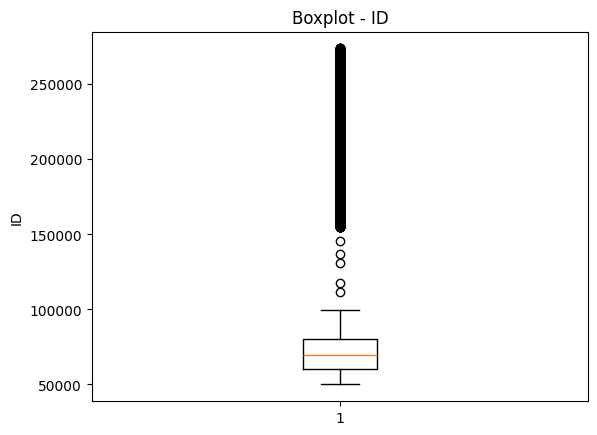

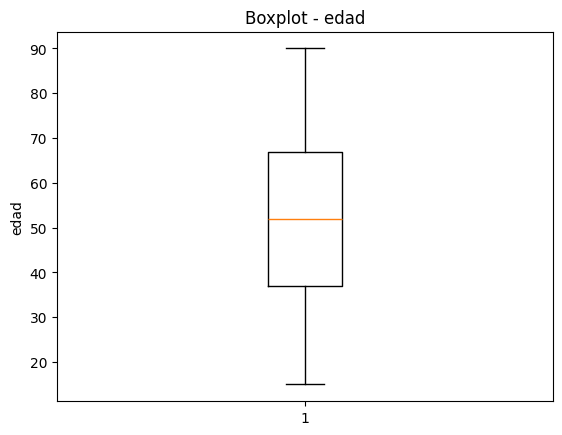

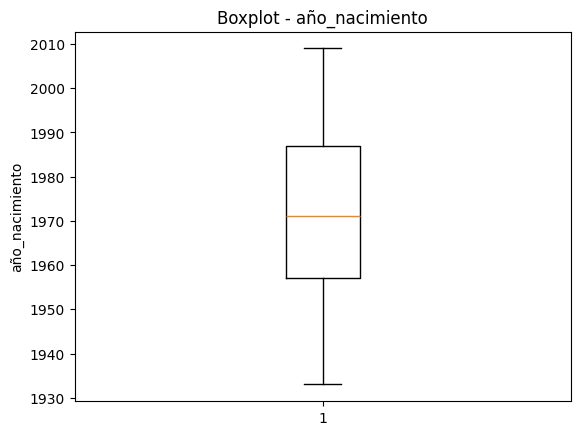

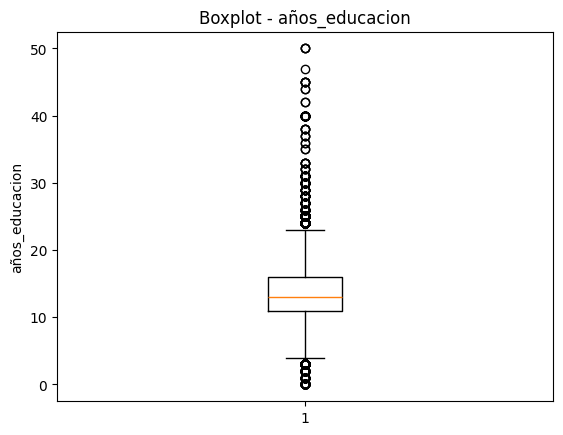

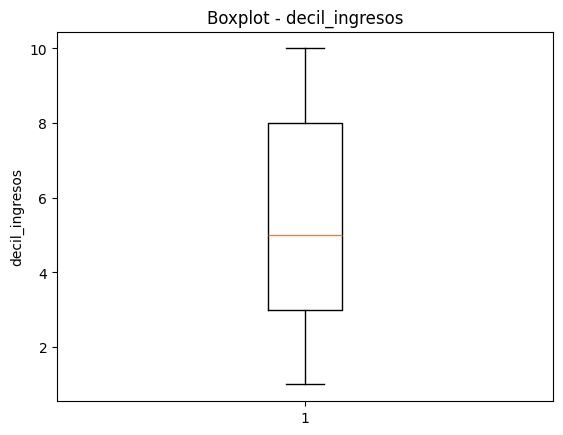

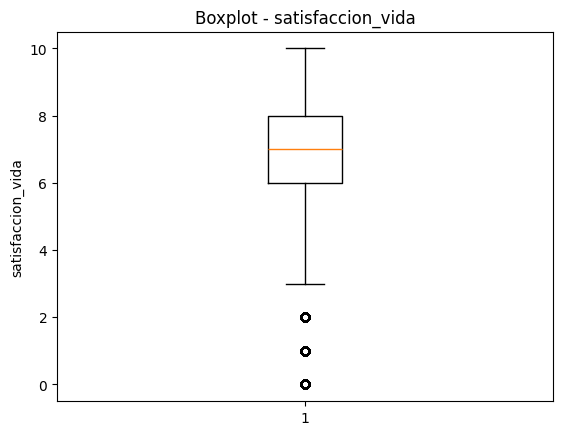

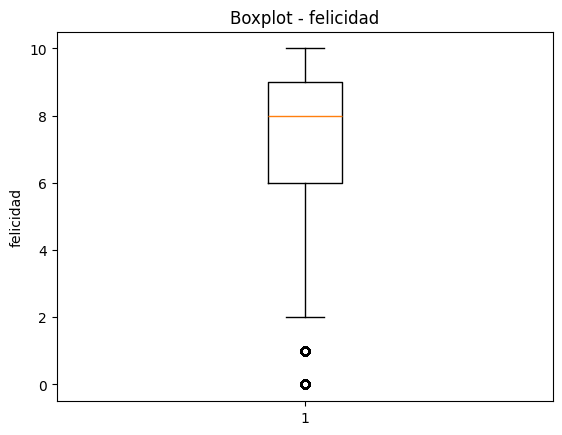

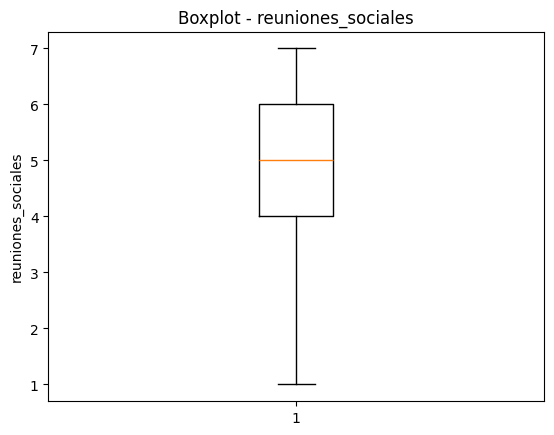

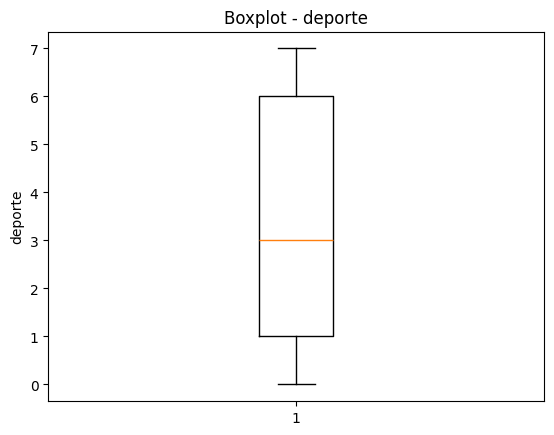

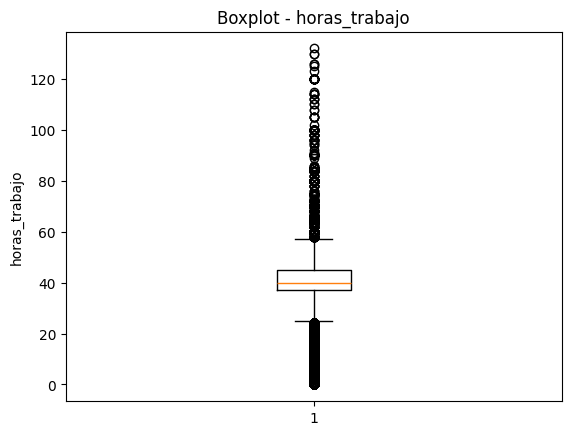

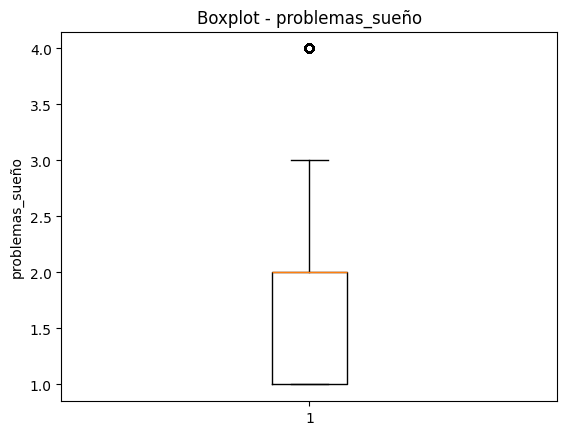

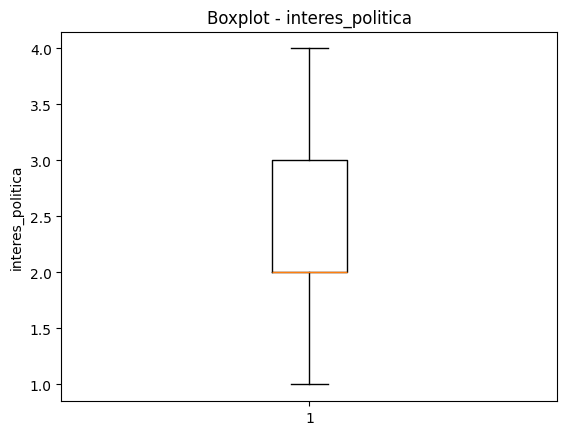

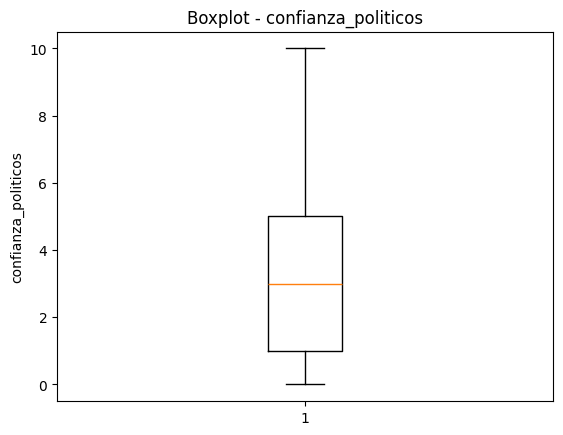

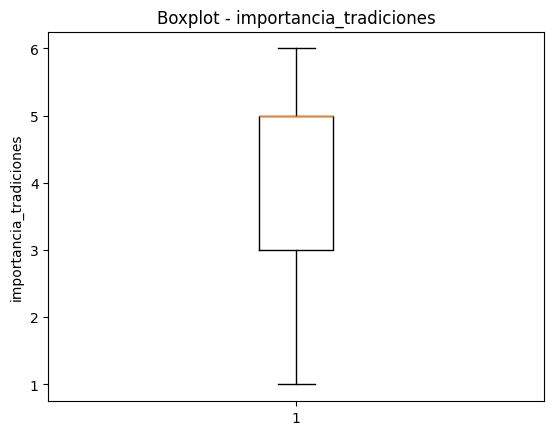

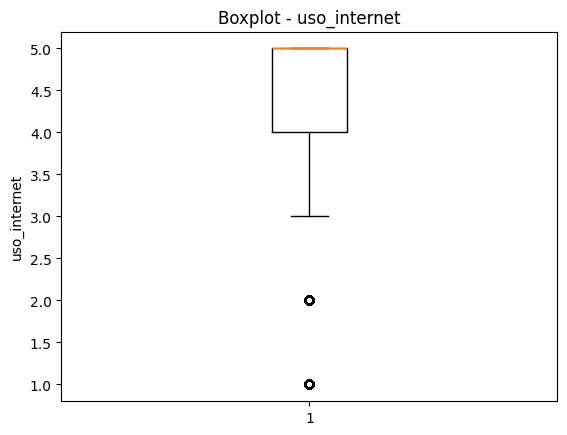

In [93]:
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.show()

In [94]:
df.to_csv("../data/datos_limpios.csv", index=False)

A continuaciñon vamos a proceder a tratar los nulos.